Study pairwise unit cross-correlation around ISR transitions

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import regions as rg
import xarray as xr
import itertools
import concurrent.futures
import os
import matplotlib.pyplot as plt
import scipy as sp
import ISRUtilities as isru
import pathlib
froot = pathlib.Path().cwd().parent / 'Figures'

test on example session

In [3]:
def _transitionCorr(session,regs=None,pairs=None,n_shuffle=0):
    # compute lagged cross-region pairwise unit correlation around NR ISR transition times as (shuffle, region, lag) XArray
    # 'shuffle' coordinate is False iff corresponding data values are real

    R = rg.data.Regions(session,states='sws',events=['InfraSlowRhythm/slownr','InfraSlowRhythm/slowavalnr'])
    regs = R.ids if regs is None else np.array(regs)
    reg_pair_idx = list(itertools.permutations(range(len(regs)),2)) if pairs is None else pairs
    reg_pairs = [f'{regs[rp[0]]}-{regs[rp[1]]}' for rp in reg_pair_idx]
    is_reg = np.isin(regs,R.ids) # is_reg[i] is True if regs[i] is in R.ids
    unit_range = {regs[i]: [R.spikes(regs[i])[:,1].min(),R.spikes(regs[i])[:,1].max()] if r else None for i, r in enumerate(is_reg)}

    # find transitions
    isr = R.eventInfo('slownr')
    on = R.eventInfo('slowavalnr')
    _, is_ok = fma.general.restrict(on[:,0]-.0001,isr,s_ind=True)
    off_on = fma.general.restrict(on[is_ok,0],R.eventIntervals('sws')).ravel() # restrict in nREM to shuffle transitions
    #_, is_ok = fma.general.restrict(on[:,1]+.0001,isr,s_ind=True)
    #on_off = on[is_ok,1]
    shuffled_off_on = np.zeros((len(off_on),n_shuffle+1)) # each column is a shuffle, first is observed
    shuffled_off_on[:,0] = off_on
    for i in range(n_shuffle):
        shuffled_off_on[:,i+1] = fma.general.shuffleEvents(off_on,intervals=R.eventIntervals('sws'))

    # analysis parameters
    win_size = 0.2
    n_strides = 7 # time resolution will be win_size / n_strides
    n_wins = 7
    limits = [-n_wins*win_size/2, n_wins*win_size/2]
    counts = {}
    times = np.full(n_wins*n_strides,np.nan)
    spearman = np.full((n_shuffle+1,len(reg_pairs),len(times)),np.nan)
    chunk_size = 100
    for k in range(0,n_shuffle+1,chunk_size):

        # concatenate chunk
        this_off_on = shuffled_off_on[:,k:k+chunk_size].ravel('F')
        this_chunk_size = len(this_off_on) // shuffled_off_on.shape[0]

        # 1. count spikes in overlapping windows around transitions, only for regions in R
        for j, r in enumerate(regs[is_reg]):
            counts[r] = np.full((this_chunk_size,len(off_on),n_wins*n_strides,int(unit_range[r][1]-unit_range[r][0])+1),np.nan) # (chunk_size, n_transitions, n_lags, n_units)
            for i in range(n_strides):
                stride = (i - n_strides//2) * win_size / n_strides
                m, t, _ = fma.analysis.PETH(R.spikes(r)[:,0],this_off_on+stride,limits=limits,n_bins=n_wins,groups=R.spikes(r)[:,1],g_range=unit_range[r],fast=True)
                counts[r][:,:,i::n_strides,:] = m.reshape((this_chunk_size,len(off_on),n_wins,int(unit_range[r][1]-unit_range[r][0])+1))
                if j == 0 and k == 0:
                    times[i::n_strides] = t + stride
            counts[r] = sp.stats.rankdata(counts[r],axis=1) # rank along transitions
            counts[r] = counts[r] - counts[r].mean(axis=1,keepdims=True) # center ranks

        # 2. average pairwise cross correlation
        for i, rp in enumerate(reg_pair_idx):
            if is_reg[rp[0]] and is_reg[rp[1]]:

                ref_centered = counts[regs[rp[0]]][:,:,(n_wins*n_strides)//2,:] # (chunk_size, n_transitions, n_units1), at lag 0 s
                lagged_centered = counts[regs[rp[1]]] # (chunk_size, n_transitions, n_lags, n_units2)

                num = np.einsum('pnm,pnlk->pmlk',ref_centered,lagged_centered) # numerator: covariance across transitions
                ref_norm = np.linalg.norm(ref_centered,axis=1) # (chunk_size, n_units1,)
                lag_norm = np.linalg.norm(lagged_centered,axis=1) # (chunk_size, n_lags, n_units2)

                with np.errstate(invalid='ignore'): # suppress 0 / 0 warning
                    spear = num / (ref_norm[:,:,None,None] * lag_norm[:,None,:,:]) # spear[p,i,l,j] is the Spearman correlation between ref_count[:,i] and counts[reg2][:,l,j] for shuffle p
                # average across unit pairs
                spearman[k:k+this_chunk_size,i,:] = np.nanmean(spear,axis=(1,3))

    xdata = xr.DataArray(spearman,dims=('shuffle','region','lag'),coords={'shuffle': [False] + [True]*n_shuffle,'region': reg_pairs,'lag': times})

    return xdata

In [2]:
def _laggedSpikeCrossCorr(session,regs=None,shift=-1,pairs=None):
    # compute lagged cross-region pairwise unit correlation around NR ISR transition times as (shuffle, region, lag) XArray
    # 'shuffle' coordinate is False iff corresponding data values are real

    R = rg.data.Regions(session,states='sws',events=['InfraSlowRhythm/slownr','InfraSlowRhythm/slowavalnr'])
    regs = R.ids if regs is None else np.array(regs)
    reg_pair_idx = list(itertools.permutations(range(len(regs)),2)) if pairs is None else pairs
    reg_pairs = [f'{regs[rp[0]]}-{regs[rp[1]]}' for rp in reg_pair_idx]
    is_reg = np.isin(regs,R.ids) # is_reg[i] is True if regs[i] is in R.ids
    unit_range = {regs[i]: [R.spikes(regs[i])[:,1].min(),R.spikes(regs[i])[:,1].max()] if r else None for i, r in enumerate(is_reg)}

    # find transitions
    isr = R.eventInfo('slownr')
    on = R.eventInfo('slowavalnr')
    _, is_ok = fma.general.restrict(on[:,0]-.0001,isr,s_ind=True)
    off_on = fma.general.restrict(on[is_ok,0],R.eventIntervals('sws')).ravel() # restrict in nREM to shuffle transitions

    # 1. count spikes in overlapping windows around event times
    win_size = 0.2
    n_strides = 7 # time resolution will be win_size / n_strides
    n_bins = 7
    limits = [-n_bins*win_size/2, n_bins*win_size/2] # could be [-0.7,0.7]
    n_times = (n_bins-1) * n_strides + 1
    counts = {}
    for j, r in enumerate(regs[is_reg]):
        m, times, _ = fma.analysis.PETH(R.spikes(r)[:,0],off_on,limits=limits,n_bins=n_bins,step=n_strides,groups=R.spikes(r)[:,1],g_range=unit_range[r],fast=True) # (n_ripples, n_lags, n_units)
        m = sp.stats.rankdata(m,axis=1) # rank along transitions
        counts[r] = m - m.mean(axis=1,keepdims=True) # center ranks

    # 2. average pairwise cross correlation, observed and shifted
    spearman = np.full((2,len(reg_pairs),n_times),np.nan)
    for i, rp in enumerate(reg_pair_idx):
        if is_reg[rp[0]] and is_reg[rp[1]]:
            # prepare observed and shifted (along events) spike counts
            ref = np.tile(counts[regs[rp[0]]][:,n_times//2,:],(2,1,1)) # (2, n_ripples, n_units1), at lag 0 s
            lagged = np.stack([counts[regs[rp[1]]], np.roll(counts[regs[rp[1]]],shift=shift,axis=0)], axis=0) # (2, n_ripples, n_lags, n_units2)

            num = np.einsum('pnm,pnlk->pmlk',ref,lagged) # numerator: covariance across events
            ref_norm = np.linalg.norm(ref,axis=1) # (2, n_units1)
            lag_norm = np.linalg.norm(lagged,axis=1) # (2, n_lags, n_units2)

            with np.errstate(invalid='ignore'): # suppress 0 / 0 warning
                spear = num / (ref_norm[:,:,None,None] * lag_norm[:,None,:,:]) # spear[p,i,l,j] is the Spearman correlation between ref_count[:,i] and counts[reg2][:,l,j] for real / shuffle
            # average across unit pairs
            spearman[:,i,:] = np.nanmean(spear,axis=(1,3))

    xdata = xr.DataArray(spearman,dims=('shuffle','region','lag'),coords={'shuffle': [False,True],'region': reg_pairs,'lag': times})

    return xdata

In [5]:
# OLD functions to compute row-wise correlation OLD

def spearmanRank(x):
    return np.argsort(np.argsort(x,axis=-1),axis=-1).astype(np.float64)

def spearmanRowCorr(a,b,window,stride=1):

    # define windows with strides (should be read-only!)
    wa = np.lib.stride_tricks.sliding_window_view(a,window,axis=1)[:,::stride,:]
    wb = np.lib.stride_tricks.sliding_window_view(b,window,axis=1)[:,::stride,:]

    # rank along last axis (inside windows)
    ra = spearmanRank(wa)
    rb = spearmanRank(wb)

    # row-wise correlations: cov(r1,r2) / (std(r1)*std(r2))
    ra -= ra.mean(axis=-1,keepdims=True)
    rb -= rb.mean(axis=-1,keepdims=True)
    num = np.sum(ra*rb,axis=-1)
    den = np.sqrt(np.sum(ra**2, axis=-1) * np.sum(rb**2, axis=-1))

    return num / den

# functions to compute statistics

def maxDeviation(x):
    return np.abs(x-np.nanmean(x)).max()

def centralMean(x,w=.25):
    return np.mean(x[int((1-w)*len(x)/2) : int((1+w)*len(x)/2)])

def centralDeviation(x,w=.25):
    return np.abs(np.mean(x[int((1-w)*len(x)/2) : int((1+w)*len(x)/2)]) - np.nanmean(x))

def workerStatistics(firing_rate,ripples,col_ind,reg_pairs,n_bins,window,stride,return_data=False):

    # surrogate ripple PETHs
    peth = []
    peth_avrg = []
    statistic_fr = []
    for r in col_ind:
        peth.append(fma.analysis.PETH(firing_rate[:,[0,r+1]],ripples,n_bins=n_bins)[0])
        peth_avrg.append(np.nanmean(peth[-1],axis=0))
        statistic_fr.append(maxDeviation(peth_avrg[-1]))

    # surrogate dfc statistics ADDED ABS
    dfc = [np.abs(spearmanRowCorr(peth[rp[0]],peth[rp[1]],window,stride=stride)) for rp in reg_pairs]
    dfc_avrg = [np.nanmean(d,axis=0) for d in dfc]
    statistic_dfc = [centralDeviation(d) for d in dfc_avrg]

    if return_data:
        return peth, dfc, statistic_fr, statistic_dfc
    return peth_avrg, dfc_avrg, statistic_fr, statistic_dfc

# function called per session

def _transitionCorr(session,regs=None,n_shuffle=0):
    # get region firing rates and their correlation around ripple times as (ripples, regions, times, shuffle) XArray
    # 'shuffle' coordinate is False iff corresponding data values are real

    R = rg.data.Regions(session,events=['InfraSlowRhythm/slownr','InfraSlowRhythm/slowavalnr'])
    regs = R.ids if regs is None else np.array(regs)
    spikes = R.spikes(regs)

    # find regs in region ids
    fr_ind = [int(np.where(R.ids==r)[0][0]) if r in R.ids else None for r in regs] # fr_ind[i] is index of regs[i] in R.ids
    reg_pair_idx = list(itertools.combinations(range(len(regs)),2))
    reg_pairs = [f'{regs[rp[0]]}-{regs[rp[1]]}' for rp in reg_pair_idx]

    # find transitions
    isr = R.eventInfo('slownr')
    on = R.eventInfo('slowavalnr')
    _, is_ok = fma.general.restrict(on[:,0]-.0001,isr,s_ind=True)
    off_on = on[is_ok,0]
    _, is_ok = fma.general.restrict(on[:,1]+.0001,isr,s_ind=True)
    on_off = on[is_ok,1]

    # make windows around 'em
    win_size = 0.2
    n_strides = 5 # time resolution will be win_size / (n_strides+2)
    n_wins = 7
    limits = [-n_wins*win_size/2, n_wins*win_size/2]
    for i in range(n_strides):
        stride = (i - n_strides//2) * win_size / (n_strides+2)
        M, t, _ = fma.analysis.PETH(spikes['pfc'],off_on+stride,limits=limits,n_bins=n_wins)

    # make lagged windows

    # count spikes





    
    # restrict in nREM to use shuffled ripples
    ripple_peaks = fma.general.restrict(R.eventInfo('ripples')[:,2],R.eventIntervals('sws'),shift=True)
    shuffled_rip = np.zeros((ripple_peaks.size,n_shuffle))
    for i in range(n_shuffle):
        shuffled_rip[:,i] = fma.general.shuffleEvents(ripple_peaks).ravel()
    firing_rate = fma.general.restrict(R.firingRate(norm=True),R.eventIntervals('sws'),shift=True)

    # observed statistics
    n_bins = 151
    t = fma.analysis.PETH([[0,0]],[0],n_bins=n_bins)[1]
    window = int(.25 // (t[1]-t[0])) # 0.25 s
    stride = int(.02 // (t[1]-t[0])) # 20 ms step between each window
    sl_time = np.interp(np.arange(0,t.size-window+1,stride) + (window-1)/2, np.arange(t.size), t) # center of each window
    fr_data, dfc_data, statistic_fr, statistic_dfc = workerStatistics(firing_rate,ripple_peaks,fr_ind,reg_pair_idx,n_bins,window,stride,return_data=True)

    # surrogate statistics
    if n_shuffle:
        # store one shuffled example
        peth_sh, dfc_sh, _, _ = workerStatistics(firing_rate,shuffled_rip[:,0],fr_ind,reg_pair_idx,n_bins,window,stride,return_data=True)
        fr_data = [fr_data,peth_sh]
        dfc_data = [dfc_data,dfc_sh]
        statistic_fr_sh = np.full((1,len(regs)),np.nan)
        statistic_dfc_sh = np.full((1,len(regs)),np.nan)
        if n_shuffle > 1:
            def worker(j):
                # closure of variables shared between workes + j indexes worker-specific columns
                return workerStatistics(firing_rate,shuffled_rip[:,j],fr_ind,reg_pair_idx,n_bins,window,stride)
            with concurrent.futures.ThreadPoolExecutor(max_workers=int(os.cpu_count()*3/4)) as executor:
                results = list(executor.map(worker, range(n_shuffle)))
            peth_sh_avrg = np.array([r[0] for r in results])
            dfc_sh_avrg = np.array([r[1] for r in results])
            statistic_fr_sh = np.array([r[2] for r in results])
            statistic_dfc_sh = np.array([r[3] for r in results])

    fr_data = xr.DataArray(np.array(fr_data,ndmin=4),dims=('shuffle','region','ripple','time'),coords={'shuffle': [False] + [True]*int(bool(n_shuffle)),
                                                                                                       'region': regs, 'time': t})
    fr_data.attrs['p_val'] = np.array([fma.analysis.MCpValue(statistic_fr_sh[:,i],statistic_fr[i]).squeeze() for i in range(len(regs))])

    dfc_data = xr.DataArray(np.array(dfc_data,ndmin=4),dims=('shuffle','region','ripple','time'),coords={'shuffle': [False] + [True]*int(bool(n_shuffle)),
                            'region': reg_pairs, 'time': sl_time})
    dfc_data.attrs['p_val'] = np.array([fma.analysis.MCpValue(statistic_dfc_sh[:,i],statistic_dfc[i]).squeeze() for i in range(len(regs))])

    peth_sh_avrg = xr.DataArray(peth_sh_avrg,dims=('shuffle','region','time'),coords={'region': regs, 'time': t})
    dfc_sh_avrg = xr.DataArray(dfc_sh_avrg,dims=('shuffle','region','time'),coords={'region': reg_pairs, 'time': sl_time})
            
    return fr_data, dfc_data, peth_sh_avrg, dfc_sh_avrg

In [3]:
regs = ['hpc','nr','pfc']
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_units.batch'

In [ ]:
# test one session
session = fma.data.readBatchFile(batch_file)[0][44]
print(f'session: {session}')
xdata = _transitionCorr(session,regs,n_shuffle=10)

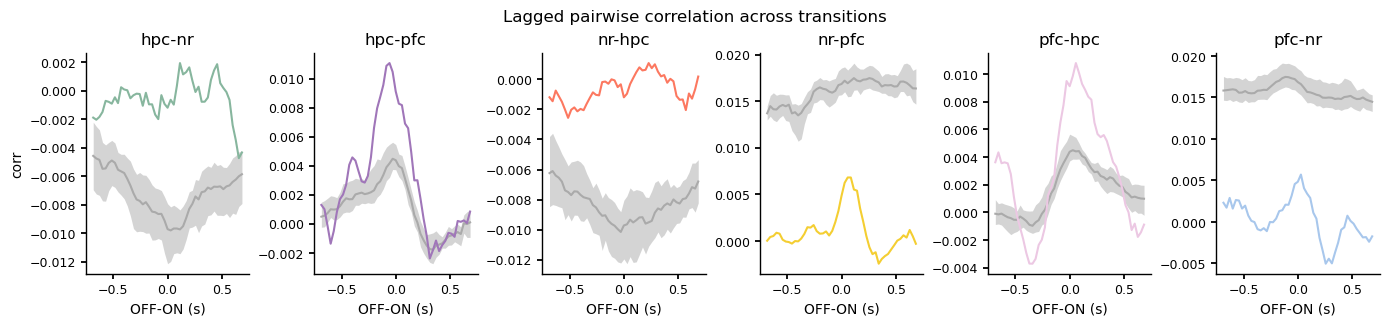

In [17]:
# interpretation: reg1 pop vector at transition correlated with reg2's delayed
fig, axs = fma.plotting.makeFigure('Lagged pairwise correlation at ISR OFF-ON transitions',[1,6],[35,8])
for i, r in enumerate(xdata['region']):
    reg_data = xdata.sel(region=r)
    fma.plotting.semPlot(xdata['lag'],reg_data.sel(shuffle=True),zscore=False,color='#AAAAAA',label=str(r.item().upper()),ax=axs[i])
    axs[i].plot(xdata['lag'],reg_data.sel(shuffle=False),color=isru.paperColors(i),label=str(r.item().upper()))
    axs[i].set_xlabel('OFF-ON (s)'), axs[i].set_title(r.values)
axs[0].set_ylabel('corr');

run batch

In [4]:
xdata = fma.data.runBatch(batch_file,_laggedSpikeCrossCorr,[[regs]],{'shift': -2},ignore_args=True,parallel=40)


Starting Batch, 2026-06-05 16:49:48.233996 

Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.xml (31)
/mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.xml (32)
/mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.xml (33)
/mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.sws not found.
Traceback:
Error in session /mnt/hubel-data-129/blinky/Rat002_20230822/Rat002_20230822.xml (41)
/mnt/hubel-data-129/blinky/Rat002_20230822/Rat002_20230822.sws not found.
Traceback:
Error in session /mnt/hubel-data-129/blinky/Rat002_20230823/Rat002_20230823.xml (42)
/mnt/hubel-data-129/blinky/Rat002_20230823/Rat002_20230823.sws not found.
Traceback:
Error in session /mnt/hubel-data-149/Rat011/Rat011

In [5]:
# concatenate data
data_cat = xr.concat([d for d in xdata if d is not None],dim='session')
# grand-average statistical test MISSING shuiffle True /!\
pval = {r.item(): fma.analysis.maxStatisticTest(data_cat.sel(region=r,shuffle=False),data_cat.sel(region=r).transpose('session','lag',...)) for r in data_cat.region}

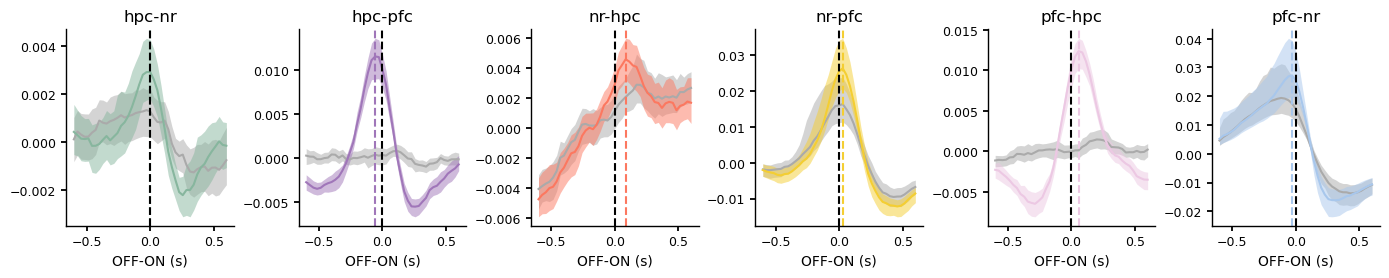

In [6]:
# Figure 2?
fig, axs = fma.plotting.makeFigure('',[1,6],size=[35,7])
for i, r in enumerate(data_cat['region'].values):
    reg_data = data_cat.sel(region=r)
    fma.plotting.semPlot(data_cat['lag'],reg_data.sel(shuffle=True),zscore=False,color='#AAAAAA',label=r.upper(),ax=axs[i])
    fma.plotting.semPlot(data_cat['lag'],reg_data.sel(shuffle=False),zscore=False,color=isru.paperColors(i),label=r.upper(),ax=axs[i])
    peak_time = np.argmax(reg_data.sel(shuffle=False).mean('session').data)
    axs[i].axvline(reg_data.lag[peak_time],ls='--',color=isru.paperColors(i)),
    axs[i].axvline(0,ls='--',color='k'), axs[i].set_xlabel('OFF-ON (s)'), axs[i].set_title(r)
    # statistical significance
    fma.plotting.pHorzLine(pval[r],data_cat['lag'],color=isru.paperColors(i),ax=axs[i])
#fma.plotting.saveFigure(fig,froot/'Figure3/Fig3g_fr_rip',['svg','png'])